# Quantum Optics - Homework 4 - Wigner function of a mechanical resonator

## Jan Chelmecki

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

$$
H / \hbar = g_0 (\sigma^+ a + \sigma^- a^{\dag})
$$

In [10]:
alpha = -1.75
N = 15
g0 = 1.0

t_R =  2*np.pi*abs(alpha)/g0
T = 15
dt = 0.01; N_Steps = int(T/dt)
times = np.linspace(0,T,N_Steps+1)
print("t_R = ", t_R)

xmax = 4
xvec = np.linspace(-xmax,xmax,201)
yvec = np.linspace(-xmax,xmax,201)

g = basis(2,0)
e = basis(2,1)

H = g0* ( tensor(destroy(2).dag(), destroy(N)) + tensor(destroy(2), destroy(N).dag()) )

t_R =  10.995574287564276


In [11]:
psi0 = tensor(g, coherent(N,alpha))
rho0 = psi0*psi0.dag()
result = mesolve(H, rho0, times)

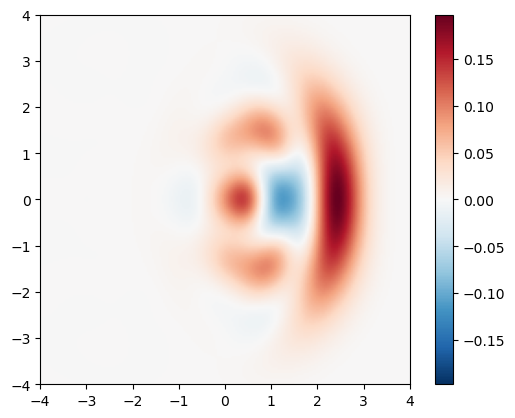

In [74]:
t = 11
rho = result.states[int(N_Steps*t/T)].ptrace(1)
W = wigner(rho, xvec, yvec)
W_max = np.max(abs(W))
plt.imshow(W,cmap="RdBu_r",vmin=-W_max,vmax=W_max, extent=[-xmax,xmax,-xmax,xmax], aspect=1)
plt.colorbar()

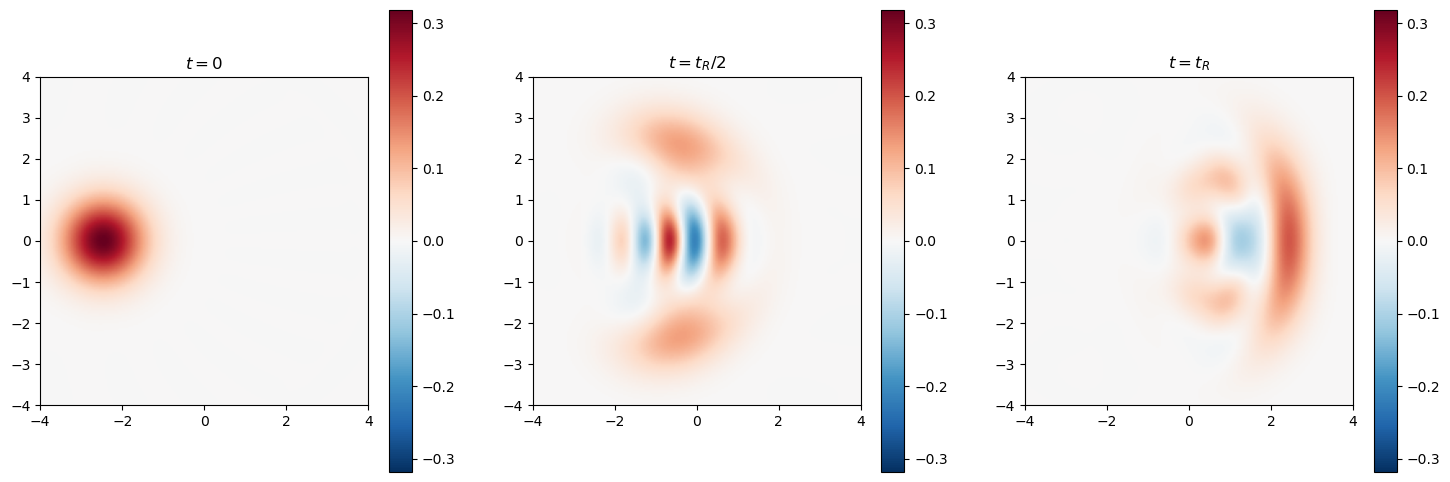

In [61]:
rho = [result.states[int(i/2*N_Steps*t_R/T)].ptrace(1) for i in range(3)]
W = [wigner(rho[i], xvec, yvec) for i in range(3)]
W_max = np.max([np.max(W[i]) for i in range(3)])
title = ["$t = 0$", "$t = t_R/2$", "$t=t_R$"]

f, ax = plt.subplots(1, 3, figsize=[18,6])
for i in range(3):
    im = ax[i].imshow(W[i],cmap="RdBu_r",vmin=-W_max,vmax=W_max, extent=[-xmax,xmax,-xmax,xmax], aspect=1)
    ax[i].set_title(title[i])
    f.colorbar(im)

In [60]:
ax[1].set_title("a")

Text(0.5, 1.0, 'a')

## Testing

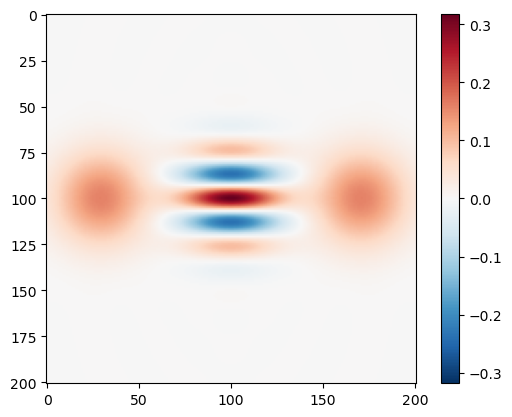

In [62]:
psi = coherent(N,alpha=2.0) + coherent(N,alpha=-2.0)
psi = psi/psi.norm()
W = wigner(psi, xvec, yvec)
W_max = np.max(abs(W))
plt.imshow(W,cmap="RdBu_r",vmin=-W_max,vmax=W_max)
plt.colorbar()

In [ ]:
plt.colorbar()

<function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | ColorizingArtist | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>